In [1]:
from collections import defaultdict
import torch
from tqdm.auto import tqdm
from matplotlib import pyplot as plt
from torch.utils.data import DataLoader
from methylseqnet.dataset import MultiMethylDataset
from methylseqnet.transforms import EncodingSelector
from methylseqnet.peaks import selected_peaks_from_target

In [2]:
dataset = MultiMethylDataset("/global/scratch/users/dixonluinenburg/atlas_datasets/borzoi-128lzf-multimethyl-bisulfite-atac-cage/fold0.h5")
interp_layer = EncodingSelector(encoding_str="interp-methyl-only")
dataloader = DataLoader(dataset, batch_size=1)
io_mappings_df = dataset.get_io_mappings_df()

  0%|          | 0/250 [00:00<?, ?it/s]

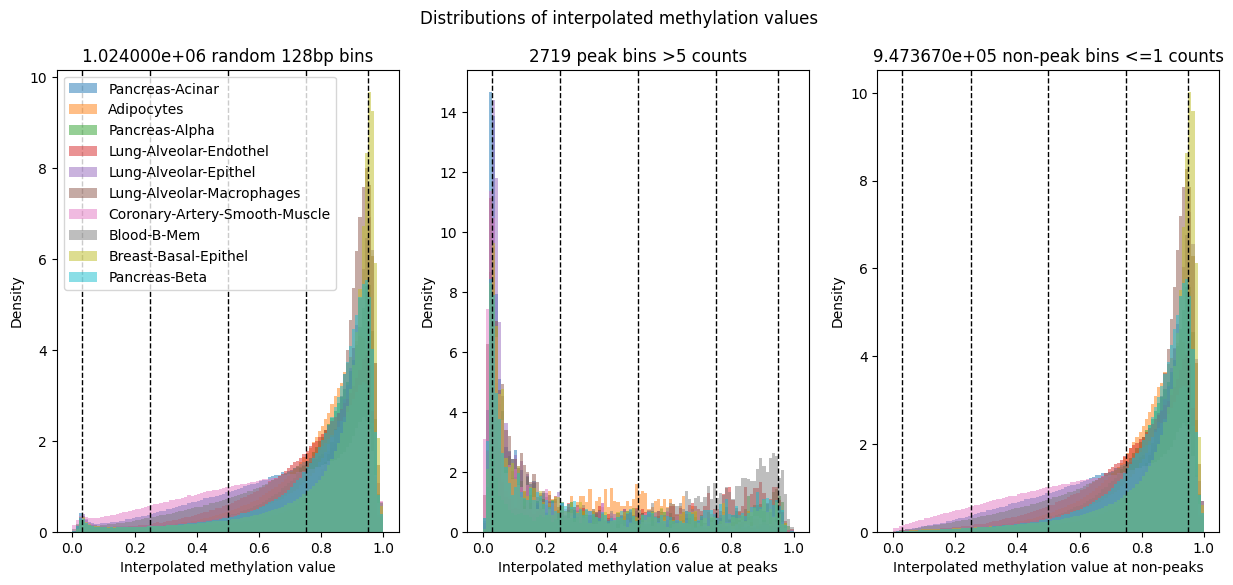

In [13]:
methyl_track_dict = defaultdict(list)
methyl_track_peaks_dict = defaultdict(list)
methyl_track_nonpeaks_dict = defaultdict(list)
peak_threshold = 5
non_peak_threshold = 1
num_samples = 250
cell_types = io_mappings_df[io_mappings_df['data_type']=='ATAC-seq']['cell_type'].tolist()[0:10]
fig, axs = plt.subplots(1,3, figsize=(15,6))
for sample in tqdm(dataloader,total=num_samples):
    for cell_type in cell_types:
        interpolated_methylation = interp_layer(torch.cat([sample['sequence'][:,0,:,:],sample['methylation'][:,0,cell_type,:,:]], dim=1))
        binned_methylation = torch.nn.functional.avg_pool1d(interpolated_methylation,kernel_size=128,stride=128)
        methyl_track_dict[cell_type].append(binned_methylation)
        target_channel_idx = io_mappings_df[(io_mappings_df['cell_type']==cell_type) & (io_mappings_df['data_type']=='ATAC-seq')]['channel'].tolist()
        target = sample['target'][:,0,target_channel_idx,:].squeeze().numpy()
        peaks = selected_peaks_from_target(target, peak_threshold=peak_threshold, min_peak_distance_bins=128)
        peak_methylation = binned_methylation[0,0,peaks]
        non_peaks = peak_indices = (target < non_peak_threshold).nonzero()[0]
        non_peak_methylation = binned_methylation[0,0,non_peaks]
        methyl_track_peaks_dict[cell_type].append(peak_methylation)
        methyl_track_nonpeaks_dict[cell_type].append(non_peak_methylation)
    if len(methyl_track_dict[cell_type]) >= num_samples:
        break
for cell_type in cell_types:
    cell_type_name = io_mappings_df[io_mappings_df['cell_type']==cell_type]['methylation_files'].values[0][2:-2]
    methyl_cat = torch.cat(methyl_track_dict[cell_type],dim=2).squeeze().numpy()
    peak_methyl_cat = torch.cat(methyl_track_peaks_dict[cell_type],dim=0).squeeze().numpy()
    non_peak_methyl_cat = torch.cat(methyl_track_nonpeaks_dict[cell_type],dim=0).squeeze().numpy()
    axs[0].hist(methyl_cat.flatten(), bins=100, range=(0,1), alpha=0.5, label=cell_type_name, density=True)
    axs[1].hist(peak_methyl_cat.flatten(), bins=100, range=(0,1), alpha=0.5, label=cell_type_name, density=True)
    axs[2].hist(non_peak_methyl_cat.flatten(), bins=100, range=(0,1), alpha=0.5, label=cell_type_name, density=True)
fig.suptitle("Distributions of interpolated methylation values")
axs[0].axvline(0.03, color='k', linestyle='dashed', linewidth=1)
axs[0].axvline(0.25, color='k', linestyle='dashed', linewidth=1)
axs[0].axvline(0.5, color='k', linestyle='dashed', linewidth=1)
axs[0].axvline(0.75, color='k', linestyle='dashed', linewidth=1)
axs[0].axvline(0.95, color='k', linestyle='dashed', linewidth=1)
axs[0].set_xlabel("Interpolated methylation value")
axs[0].set_ylabel("Density")
axs[0].set_title(f"{len(methyl_cat):e} random 128bp bins")
axs[0].legend()
axs[1].axvline(0.03, color='k', linestyle='dashed', linewidth=1)
axs[1].axvline(0.25, color='k', linestyle='dashed', linewidth=1)
axs[1].axvline(0.5, color='k', linestyle='dashed', linewidth=1)
axs[1].axvline(0.75, color='k', linestyle='dashed', linewidth=1)
axs[1].axvline(0.95, color='k', linestyle='dashed', linewidth=1)
axs[1].set_xlabel("Interpolated methylation value at peaks")
axs[1].set_ylabel("Density")
axs[1].set_title(f"{len(peak_methyl_cat)} peak bins >{peak_threshold} counts")
axs[2].axvline(0.03, color='k', linestyle='dashed', linewidth=1)
axs[2].axvline(0.25, color='k', linestyle='dashed', linewidth=1)
axs[2].axvline(0.5, color='k', linestyle='dashed', linewidth=1)
axs[2].axvline(0.75, color='k', linestyle='dashed', linewidth=1)
axs[2].axvline(0.95, color='k', linestyle='dashed', linewidth=1)
axs[2].set_xlabel("Interpolated methylation value at non-peaks")
axs[2].set_ylabel("Density")
axs[2].set_title(f"{len(non_peak_methyl_cat):e} non-peak bins <={non_peak_threshold} counts")
plt.show()

Text(0.5, 1.0, '9.069924e+05 non-peak bins <=1 counts')

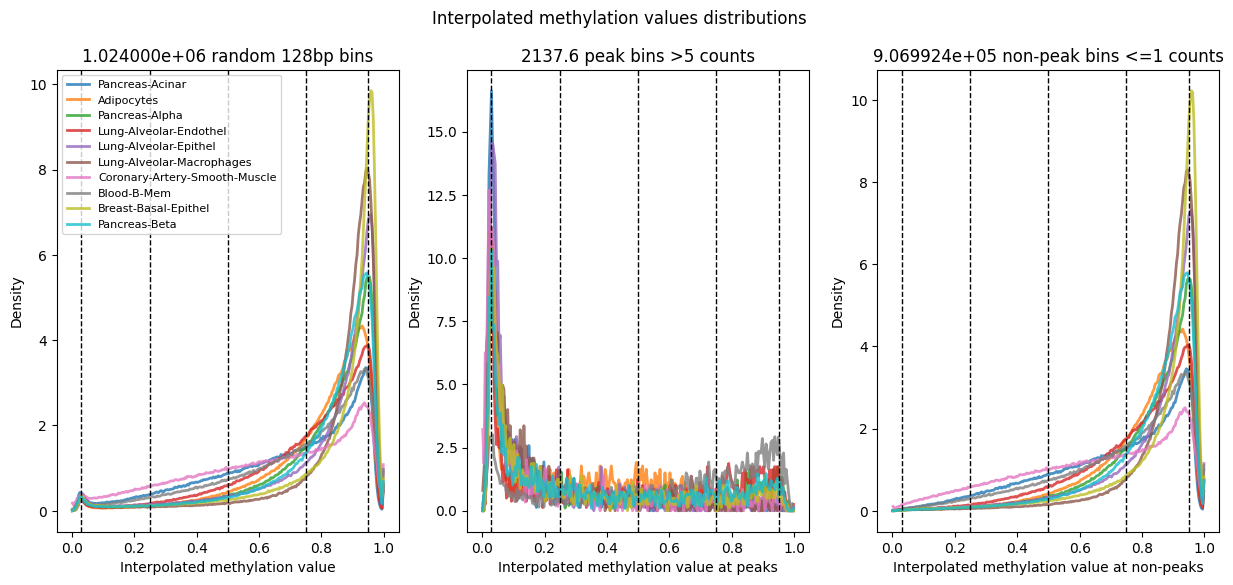

In [18]:
from matplotlib.collections import PolyCollection
import numpy as np

fig, axs = plt.subplots(1,3, figsize=(15,6))
fig.suptitle("Interpolated methylation values distributions")

peak_bins_ct = 0
nonpeak_bins_ct = 0

for cell_type in cell_types:
    cell_type_name = io_mappings_df[io_mappings_df['cell_type']==cell_type]['methylation_files'].values[0][2:-2]
    methyl_cat = torch.cat(methyl_track_dict[cell_type],dim=2).squeeze().numpy()
    peak_methyl_cat = torch.cat(methyl_track_peaks_dict[cell_type],dim=0).squeeze().numpy()
    non_peak_methyl_cat = torch.cat(methyl_track_nonpeaks_dict[cell_type],dim=0).squeeze().numpy()

    peak_bins_ct += peak_methyl_cat.shape[0]
    nonpeak_bins_ct += non_peak_methyl_cat.shape[0]
    
    hist, bins = np.histogram(methyl_cat.flatten(), bins=250, range=(0,1), density=True)
    bin_centers = (bins[:-1] + bins[1:]) / 2
    axs[0].plot(bin_centers, hist, label=cell_type_name, linewidth=2, alpha=0.8)
    hist_peaks, bins_peaks = np.histogram(peak_methyl_cat.flatten(), bins=250, range=(0,1), density=True)
    bin_centers_peaks = (bins_peaks[:-1] + bins_peaks[1:]) / 2
    axs[1].plot(bin_centers_peaks, hist_peaks, label=cell_type_name, linewidth=2, alpha=0.8)
    hist_nonpeaks, bins_nonpeaks = np.histogram(non_peak_methyl_cat.flatten(), bins=250, range=(0,1), density=True)
    bin_centers_nonpeaks = (bins_nonpeaks[:-1] + bins_nonpeaks[1:]) / 2
    axs[2].plot(bin_centers_nonpeaks, hist_nonpeaks, label=cell_type_name, linewidth=2, alpha=0.8)


setpoints = [0.03, 0.25, 0.5, 0.75, 0.95]
for setpoint in setpoints:
    axs[0].axvline(setpoint, color='k', linestyle='dashed', linewidth=1)
    axs[1].axvline(setpoint, color='k', linestyle='dashed', linewidth=1)
    axs[2].axvline(setpoint, color='k', linestyle='dashed', linewidth=1)

axs[0].legend(fontsize=8)
axs[0].set_xlabel("Interpolated methylation value")
axs[0].set_ylabel("Density")
axs[0].set_title(f"{len(methyl_cat):e} random 128bp bins")
axs[1].set_xlabel("Interpolated methylation value at peaks")
axs[1].set_ylabel("Density")
axs[1].set_title(f"{peak_bins_ct/len(cell_types)} peak bins >{peak_threshold} counts")
axs[2].set_xlabel("Interpolated methylation value at non-peaks")
axs[2].set_ylabel("Density")
axs[2].set_title(f"{nonpeak_bins_ct/len(cell_types):e} non-peak bins <={non_peak_threshold} counts")